In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
from net.network import *

# Results

In [2]:
num_element=[32]
eq=['inputcoeff']
folder=['FCNN_epochs50000_20250625T142010']

### Data load

In [3]:
idx=0

In [4]:
mesh=np.load('mesh_1DP1/ne{}_{}.npz'.format(num_element[idx],eq[idx]))
NUM_ELEMENT, NUM_PTS, p, c= mesh['ne'], mesh['ng'], mesh['p'], mesh['c']

In [5]:
NUM_ELEMENT, NUM_PTS

(array(32), array(64))

In [6]:
from torch.utils.data import Dataset, DataLoader
import pickle

In [7]:
NUM_DATA=1000
BATCH_SIZE=NUM_DATA

In [8]:
from torch.utils.data import Dataset as TorchDataset, DataLoader

class PlotDataset(TorchDataset):
    def __init__(self, file, basis_order, mesh, kind='train'):
        self.pickle_file = file
        self.basis_order = basis_order

        # Load the pickle data
        with open(f'data/P{basis_order}/{kind}/' + self.pickle_file + '.pkl', 'rb') as f:
            self.data = pickle.load(f)

        # Load matrices from mesh .npz
        self.input_matrix = mesh[f'{kind}_matrix']      # (num_data, N, N)
        self.load_vector  = mesh[f'{kind}_load_vector'] # (num_data, N)
        self.stiff_matrix = mesh[f'{kind}_stiff']       # (num_data, N, N)

    def __getitem__(self, idx):
        coeff_u   = torch.FloatTensor(self.data[idx, 0]).unsqueeze(0)
        c_value   = torch.FloatTensor(self.data[idx, 1]).unsqueeze(0)
        coeff_c   = torch.FloatTensor(self.data[idx, 2])
        input_mat = torch.FloatTensor(self.input_matrix[idx])
        load_vec  = torch.FloatTensor(self.load_vector[idx])
        stiff_mat = torch.FloatTensor(self.stiff_matrix[idx])

        return {
            'coeff_u': coeff_u,
            'c_value': c_value,
            'coeff_c': coeff_c,
            'input_matrix': input_mat,
            'load_vector': load_vec,
            'stiff': stiff_mat,
        }

    def __len__(self):
        return len(self.data)

from torch.utils.data import Dataset as TorchDataset, DataLoader

BASIS_ORDER = 1  # because you used mesh_1DP1
file_name = f'1000N{num_element[idx]}_{eq[idx]}'  # same pattern as before

gparams = {'file': file_name}  # minimal gparams for the Dataset

class MyDataset(TorchDataset):
    def __init__(self, gparams, mesh, kind='train'):
        self.pickle_file = gparams['file']
        with open(f'data/P{BASIS_ORDER}/{kind}/' + self.pickle_file + '.pkl', 'rb') as f:
            self.data = pickle.load(f)

        self.input_matrix = mesh[f'{kind}_matrix']      # (num_data, N, N)
        self.load_vector  = mesh[f'{kind}_load_vector'] # (num_data, N)
        self.stiff_matrix = mesh[f'{kind}_stiff']       # (num_data, N, N)

    def __getitem__(self, idx):
        coeff_u   = torch.FloatTensor(self.data[idx, 0]).unsqueeze(0)
        c_value   = torch.FloatTensor(self.data[idx, 1]).unsqueeze(0)
        coeff_c   = torch.FloatTensor(self.data[idx, 2])
        input_mat = torch.FloatTensor(self.input_matrix[idx])
        load_vec  = torch.FloatTensor(self.load_vector[idx])
        stiff_mat = torch.FloatTensor(self.stiff_matrix[idx])

        return {
            'coeff_u': coeff_u,
            'c_value': c_value,
            'coeff_c': coeff_c,
            'input_matrix': input_mat,
            'load_vector': load_vec,
            'stiff': stiff_mat,
        }

    def __len__(self):
        return len(self.data)

# Now create loaders
lg_dataset = MyDataset(gparams, mesh, kind='train')
trainloader = DataLoader(lg_dataset, batch_size=BATCH_SIZE, shuffle=True)

lg_dataset = MyDataset(gparams, mesh, kind='validate')
validateloader = DataLoader(lg_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [9]:
for validate_data in validateloader:
    coeff_u = validate_data['coeff_u']
    data_c = validate_data['c_value']
    coeff_c = validate_data['coeff_c']



In [10]:
data_c.shape

torch.Size([1000, 1, 64])

In [11]:
model_FEM = FCNN('silu', 1, 32, NUM_PTS, kernel_size=5, padding=2, blocks=4)
#model_FEM=model_FEM.cuda()

In [12]:
import os
PATH=os.path.join('train', "P1", f'1000N'+str(num_element[idx])+f'_{eq[idx]}',folder[idx])

In [13]:
import os

#base_path = "train/P1/1000N32_inputcoeff/FCNN_epochs80000_20251201T223559/"
base_path = "train/P1/1000N32_inputcoeff/"

# List all available folders
folders = os.listdir(base_path)

# Sort folders based on modification time
latest_folder = max(folders, key=lambda f: os.path.getmtime(os.path.join(base_path, f)))
model_path = os.path.join(base_path, latest_folder, "model.pt")
#model_path = os.path.join(base_path, "model.pt")

print("Using Model Path:", model_path) 


Using Model Path: train/P1/1000N32_inputcoeff/FCNN_epochs120000_20251203T095323/model.pt


In [14]:
import torch

# Load model from the latest folder
state_dict = torch.load(model_path, map_location=torch.device('cpu'))


In [15]:
model_FEM.load_state_dict(state_dict['model_state_dict'])

<All keys matched successfully>

In [16]:
def rel_L2_error(pred, true):
    return (torch.sum((true-pred)**2, axis=-1)/torch.sum((true)**2, axis=-1))**0.5

983
Error:0.046533599495887756


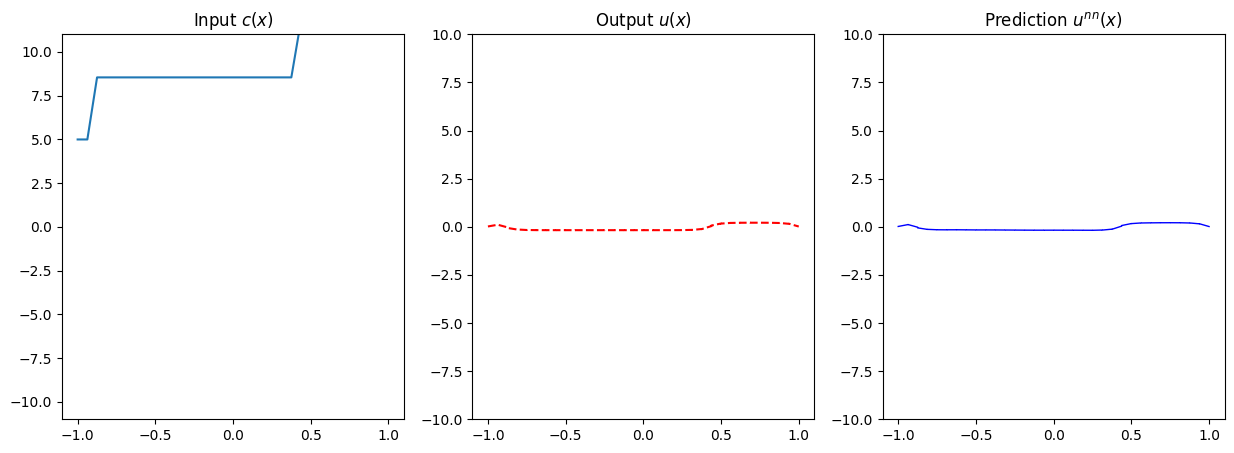

In [17]:
plot_idx=np.random.randint(1000)
#plot_idx=482
print(plot_idx)
c = data_c[[plot_idx]]#.cuda()
u = coeff_u[[plot_idx]]
output_u=model_FEM(c)

fig=plt.figure(figsize=(15,5))
ax=plt.subplot(1,3,1)
ax.set_title(r'Input $c(x)$')
ax.plot(p[p.argsort()],c.squeeze()[p.argsort()])
ax.set_ylim(-11,11)

ax=plt.subplot(1,3,2)
ax.set_title(r'Output $u(x)$')
ax.plot(p[p.argsort()],u.squeeze()[p.argsort()], c='r',linestyle='--')
ax.set_ylim(-10,10)

ax=plt.subplot(1,3,3)
ax.set_title(r'Prediction $u^{nn}(x)$')
#ax.plot(p[p.argsort()],u.squeeze()[p.argsort()], c='r',linestyle='--')
ax.plot(p[p.argsort()],output_u.squeeze().detach()[p.argsort()], c='b', linewidth=1)
ax.set_ylim(-10,10)

print("Error:{}".format(rel_L2_error(output_u.squeeze().detach(),u.squeeze())))

Plotting sample index: 159


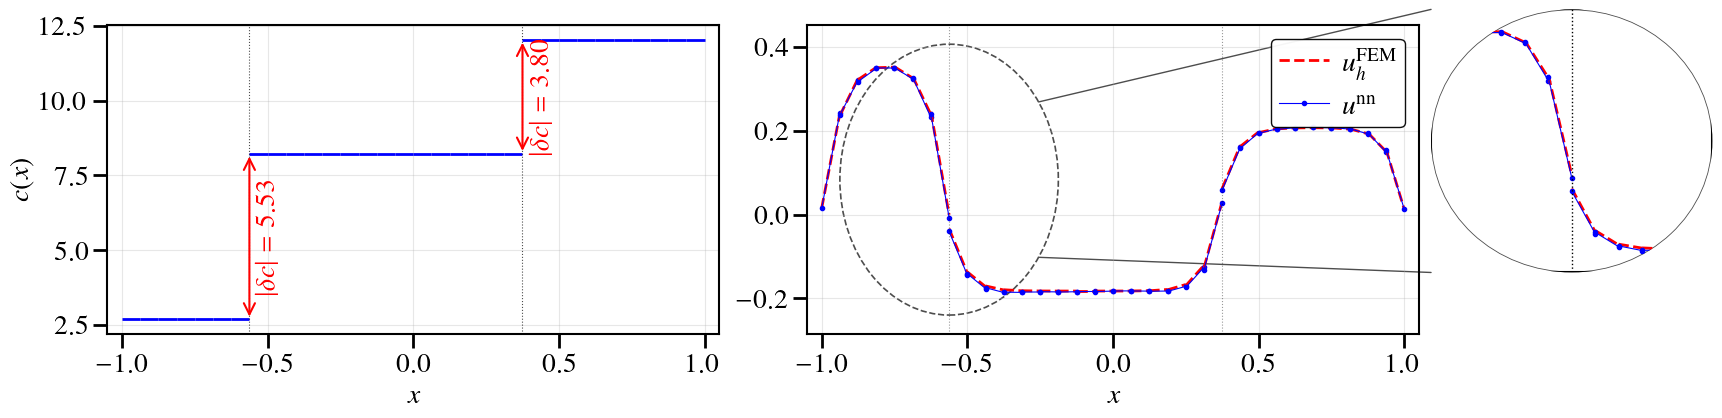

Relative L2 Error: 0.0153


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Ellipse, ConnectionPatch
import matplotlib.patches as patches

# -------- Global figure style: LaTeX + Times (txfonts), consistent with other figures --------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"""
        \usepackage{amsmath,amssymb,amsfonts}
        \usepackage{txfonts}
    """,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.size": 20,
    "lines.linewidth": 4,
    "lines.markersize": 10,
    "axes.linewidth": 1.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
})

# -------- control magnification (>=1) --------
MAGNIFY_FACTOR = 1.0  # 1.0 = no extra magnification; 2.0 makes the lens half the previous size

# -------- Pick a sample and evaluate model --------
plot_idx = np.random.randint(1000)
plot_idx = 159
print("Plotting sample index:", plot_idx)

c_sample = data_c[[plot_idx]]
u_sample = coeff_u[[plot_idx]]
output_u = model_FEM(c_sample)

# tensors -> numpy
c_vals = c_sample.squeeze().detach().cpu().numpy() if torch.is_tensor(c_sample) else c_sample.squeeze().numpy()
u_vals = u_sample.squeeze().detach().cpu().numpy()
output_vals = output_u.squeeze().detach().cpu().numpy()

p_vals = np.array(p)
c_dofmap = np.array(mesh['c'], dtype=object)
NUM_ELEMENT = len(c_dofmap)

error = rel_L2_error(output_u.squeeze().detach(), u_sample.squeeze())

# -------- figure & axes (use constrained_layout) --------
fig, (ax_c, ax_u) = plt.subplots(
    1, 2, figsize=(14.2, 4.0), constrained_layout=True
)

# =======================
# Left: piecewise c(x)
# =======================
for i in range(NUM_ELEMENT):
    local_dofs = np.array(c_dofmap[i], dtype=np.int64)
    x_local = p_vals[local_dofs]
    y_val = c_vals[local_dofs][0]
    x_min, x_max = np.min(x_local), np.max(x_local)

    # piecewise-constant blue segments (keep color)
    ax_c.hlines(y=y_val, xmin=x_min, xmax=x_max, color='b', linewidth=2)

    # mark jumps
    if i > 0:
        prev_dofs = np.array(c_dofmap[i-1], dtype=np.int64)
        c_prev = c_vals[prev_dofs][0]
        if np.abs(c_prev - y_val) > 1e-4:
            jump_x = x_min
            jump_y = 0.5 * (c_prev + y_val)
            jump_val = abs(c_prev - y_val)
            ax_c.annotate(
                '',
                xy=(jump_x, c_prev),
                xytext=(jump_x, y_val),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5)
            )
            ax_c.text(
                jump_x + 0.02, jump_y,
                r'$|\delta c| = {:.2f}$'.format(jump_val),
                color='red', fontsize=20, va='center', rotation=90
            )

ax_c.set_xlabel(r'$x$')
ax_c.set_ylabel(r'$c(x)$')
ax_c.grid(True, alpha=0.3)
ax_c.set_xlim(-1.05, 1.05)
ax_c.set_ylim(np.min(c_vals) - 0.5, np.max(c_vals) + 0.5)
ax_c.tick_params(axis='both', which='major')

for spine in ['top', 'right', 'bottom', 'left']:
    ax_c.spines[spine].set_visible(True)

# =======================
# Right: u(x) truth vs pred
# =======================
for i in range(NUM_ELEMENT):
    local_dofs = np.array(c_dofmap[i], dtype=np.int64)
    x_local = p_vals[local_dofs]
    y_truth = u_vals[local_dofs]
    y_pred  = output_vals[local_dofs]
    si = np.argsort(x_local)

    # DG Truth: red dashed
    ax_u.plot(
        x_local[si], y_truth[si],
        'r--', linewidth=2.0,
        label=r'$u_h^{\mathrm{FEM}}$' if i == 0 else ""
    )

    # DG-FEONet: blue with markers
    ax_u.plot(
        x_local[si], y_pred[si],
        'bo-', markersize=3, linewidth=0.8,
        label=r'$u^{\mathrm{nn}}$' if i == 0 else ""
    )

ax_u.set_xlabel(r'$x$')
#ax_u.set_ylabel(r'$u(x)$')
ax_u.grid(True, alpha=0.3)
ax_u.set_xlim(-1.05, 1.05)
ax_u.set_ylim(
    np.min([np.min(u_vals), np.min(output_vals)]) - 0.1,
    np.max([np.max(u_vals), np.max(output_vals)]) + 0.1
)
ax_u.tick_params(axis='both', which='major')

for spine in ['top', 'right', 'bottom', 'left']:
    ax_u.spines[spine].set_visible(True)

# Legend in upper-right with box (same style as other figures)
ax_u.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.95,
    edgecolor='black',
    fontsize=20,
    handlelength=1.8,
    handletextpad=0.5,
    borderpad=0.3,
    columnspacing=0.8
)

# =====================================================
# Find jump location from c(x) and define zoom window
# =====================================================
jumps = []
for i in range(1, NUM_ELEMENT):
    prev_dofs = np.array(c_dofmap[i-1], dtype=np.int64)
    curr_dofs = np.array(c_dofmap[i], dtype=np.int64)
    c_prev = c_vals[prev_dofs][0]
    c_curr = c_vals[curr_dofs][0]
    if abs(c_prev - c_curr) > 1e-6:
        x_edge = np.min(p_vals[curr_dofs])  # left edge of current cell
        jumps.append((x_edge, abs(c_prev - c_curr)))

x_jump = max(jumps, key=lambda t: t[1])[0] if jumps else 0.0

x_unique = np.sort(np.unique(p_vals))
h = np.min(np.diff(x_unique)) if len(x_unique) > 1 else 0.05
half_width = 6 * h
x0, x1 = x_jump - half_width, x_jump + half_width

mask = (p_vals >= x0) & (p_vals <= x1)
if not np.any(mask):
    idx0 = int(np.argmin(np.abs(p_vals - x_jump)))
    lo = max(0, idx0 - 6)
    hi = min(len(p_vals) - 1, idx0 + 6)
    x0, x1 = p_vals[lo], p_vals[hi]
    mask = (p_vals >= x0) & (p_vals <= x1)

ymin_win = min(np.min(u_vals[mask]), np.min(output_vals[mask]))
ymax_win = max(np.max(u_vals[mask]), np.max(output_vals[mask]))
pad = 0.10 * max(ymax_win - ymin_win, 1e-6)

# =====================================================
# Inset placed OUTSIDE the right subplot 
# =====================================================
axins = inset_axes(
    ax_u,
    width="46%", height="85%",        # size relative to ax_u
    loc="upper left",
    bbox_to_anchor=(1.02, 0.05, 1, 1),  # push outside to the right
    bbox_transform=ax_u.transAxes,
    borderpad=0.0
)

# replot into inset (same colors/styles)
for i in range(NUM_ELEMENT):
    local_dofs = np.array(c_dofmap[i], dtype=np.int64)
    x_local = p_vals[local_dofs]
    y_truth = u_vals[local_dofs]
    y_pred  = output_vals[local_dofs]
    si = np.argsort(x_local)
    axins.plot(x_local[si], y_truth[si], 'r--', linewidth=2.0)
    axins.plot(x_local[si], y_pred[si],  'bo-', markersize=3, linewidth=0.8)

axins.set_xlim(x0, x1)
axins.set_ylim(ymin_win - pad, ymax_win + pad)
axins.grid(True, alpha=0.4)
axins.set_xticks([])
axins.set_yticks([])
axins.axvline(x_jump, linestyle=':', linewidth=1.0, color='k')

# =====================================================
# Circular lens on main plot
# =====================================================
y_center = 0.5 * (ymin_win + ymax_win)

# Full-window radii (data units)
rx_full = 0.5 * (x1 - x0)
ry_full = 0.5 * ((ymax_win + pad) - (ymin_win - pad))

# Shrink the lens by MAGNIFY_FACTOR to increase apparent magnification
rx = rx_full / max(MAGNIFY_FACTOR, 1.0)
ry = ry_full / max(MAGNIFY_FACTOR, 1.0)

# Draw lens (ellipse in data coords)
lens = Ellipse(
    (x_jump, y_center),
    width=2*rx, height=2*ry,
    fill=False, linestyle='--', linewidth=1.2, edgecolor='0.3'
)
ax_u.add_patch(lens)

# Connect lens to inset with clean leader lines
angles = (np.deg2rad(35), np.deg2rad(-35))
pts_main = [(x_jump + rx*np.cos(a), y_center + ry*np.sin(a)) for a in angles]
pts_inset = [(0, 1), (0, 0)]  # top-left and bottom-left corners of inset

for (xa, ya), (xb, yb) in zip(pts_main, pts_inset):
    conn = ConnectionPatch(
        xyA=(xa, ya), coordsA='data', axesA=ax_u,
        xyB=(xb, yb), coordsB='axes fraction', axesB=axins,
        ec='0.3', lw=1.0
    )
    ax_u.add_artist(conn)

# OPTIONAL: make the inset itself circular (loupe look)
clip_circle = mpl.patches.Circle(
    (0.5, 0.5), 0.5, transform=axins.transAxes,
    fill=False, ec='0.3', lw=1.2
)
axins.add_patch(clip_circle)
axins.patch.set_alpha(0.0)  # hide rectangular patch
for artist in axins.get_children():
    if hasattr(artist, 'set_clip_path'):
        artist.set_clip_path(clip_circle)

# dotted lines for all jumps
for xj, _ in jumps:
    ax_c.axvline(xj, color='k', linestyle=':', linewidth=0.8, alpha=0.7)
    ax_u.axvline(xj, color='k', linestyle=':', linewidth=0.8, alpha=0.4)

plt.savefig("DG_FEONet_Discontinuous_var_eps_159_new.png", format='png', bbox_inches='tight')
plt.show()
print("Relative L2 Error: {:.4f}".format(error))
